# Assignment 2 – Zero-Shot Image Classification with Transformers

In this assignment, you will apply a pre-trained vision–language transformer (e.g. CLIP) to perform **zero-shot** classification on the Fashion-MNIST dataset—classifying each image without any task-specific training. You will build on the concepts from Assignment 1 by comparing this “off-the-shelf” approach to the CNN you previously trained.

You will:
1. **Load** the Fashion-MNIST images using PyTorch instead of Keras.
2. **Run a zero-shot baseline** with simple text prompts to set a performance reference.
3. **Engineer improved prompts** and measure the resulting accuracy gains.
4. **Visualise image embeddings** with UMAP to inspect class separability.
5. **Conduct one mini-experiment** of your choice.
6. **Summarise findings** and reflect on strengths and weaknesses of zero-shot transformers versus a trained CNN.

# 1. Loading the Fashion-MNIST Dataset

As in assignment 1, we'll load the Fashion-MNIST dataset, but this time using `torchvision.datasets` to ensure compatibility with the `transformers` library. We will also load our model and processor from the `transformers` library.

The transformers library allows us to use pre-trained models like CLIP, which can perform zero-shot classification by leveraging the text prompts we provide. There are two key objects we will use: the `CLIPModel` for the model itself and the `CLIPProcessor` for preparing our images and text prompts.

Since we are not actually training a model in this assignment, we will set the CLIP model to evaluation mode. If the model is designed to utilize features like dropout or batch normalization, setting it to evaluation mode ensures that these features behave correctly during inference (prediction). Setting the model to evaluaton mode also tells PyTorch that we don't have to compute gradients, which can save memory and speed up inference.

In order to speed up processing, we will also move the model to an "accelerator" if available. This is typically a GPU, but modern MacBooks also have an "Apple Silicon" accelerator that can be used for inference, called MPS (Metal Performance Shaders). If you are using a MacBook with Apple Silicon, you can use the MPS device for faster processing.

In [152]:
#debug only
import sys
import torch

def where_i_run ():
    if 'google.colab' in sys.modules:
        print("You are running this notebook in Google Colab.")
    else:
        print("You are running a standard Jupyter Notebook locally or on another server.")

    print(torch.cuda.is_available())
    print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

where_i_run()

You are running a standard Jupyter Notebook locally or on another server.
True
NVIDIA GeForce RTX 4070 Laptop GPU


In [153]:
# must install "transformers==4.51.0"
import transformers
from packaging import version

required_version = "4.51.0"

if version.parse(transformers.__version__) != version.parse(required_version):
    print(f"Current transformers version: {transformers.__version__}")
    print(f"Installing transformers {required_version}...")
    !pip install -q --upgrade transformers==4.51.0
    print("Please restart the kernel/runtime.")
else:
    print("Correct transformers version (4.51.0) installed.")

Correct transformers version (4.51.0) installed.


In [154]:
# Uncomment and run if required
#!pip install transformers torchvision torch accelerate

In [155]:
from transformers import CLIPModel, CLIPProcessor
import torch

clip_model_name = "openai/clip-vit-base-patch32"
clip_model     = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name, use_fast=False)

# Set model to evaluation mode, as we are not training it
clip_model.eval()

# Check for accelerators
device = "cpu" # Default to CPU
if torch.cuda.is_available():
    device = "cuda" # Use GPU if available
elif torch.backends.mps.is_available():
    device = "mps"

clip_model.to(device)

print(f"Using device: {device}")

Using device: cuda


Now we are ready to load the testing set from Fashion-MNIST. We will use the `torchvision.datasets.FashionMNIST` class to load the dataset. We do not need to apply any transformations to the images, as the `CLIPProcessor` ensures any input images are in the format that the model is trained on.

You should:

- [ ] Use the `torchvision.datasets.FashionMNIST` class to load the *test* split of the dataset. Documentation is available [here](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).
- [ ] Create a PyTorch `DataLoader` to iterate over the dataset in batches. Use a batch size of 16 and set `shuffle=True` to randomise the order of the images. You will also need to supply the provided `collate_clip` function to the `DataLoader collate_fn` argument to ensure the images are processed correctly. Documentation for `DataLoader` is available [here](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

In [156]:
from torchvision import datasets
from torch.utils.data import DataLoader

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

def collate_clip(batch):
    imgs, labels = zip(*batch) # Unzip the batch into images and labels
    proc = clip_processor(images=list(imgs),
                        return_tensors="pt",
                        padding=True) # Process images with CLIPProcessor
    # Send pixel_values to GPU/CPU now; labels stay on CPU for metrics
    return proc["pixel_values"].to(device), torch.tensor(labels)

# test_dataset = # Complete
# test_loader = # Complete

########
# Load the Fashion-MNIST test dataset
test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True
)

# Create the DataLoader
def fashion_mnist_test_loader():
    test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_clip
    )
    return test_loader

#### Run test_loader again if the model has changed.
test_loader = fashion_mnist_test_loader()

########

If your code is correct, the following cell should show the first batch of images from the Fashion-MNIST dataset:

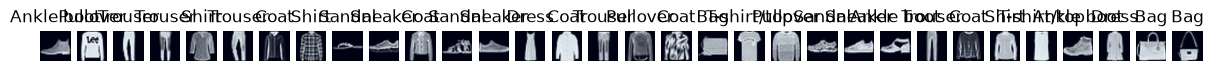

In [157]:
import matplotlib.pyplot as plt

# Display the first batch of images from `test_loader`

def show_batch(loader):
    images, labels = next(iter(loader))
    images = images.cpu()  # Move images to CPU for plotting
    # Renormalize to [0, 1] for visualization
    images = (images - images.min()) / (images.max() - images.min())
    _, axes = plt.subplots(1, len(images), figsize=(15, 5))
    for ax, img, label in zip(axes, images, labels):
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(CLASS_NAMES[label.item()])
        ax.axis('off')
    plt.show()

show_batch(test_loader)

We’re now ready to run our zero-shot classification baseline!

# Brief Introduction to Zero-Shot Classification

In Assignment 1, we followed the typical machine-learning pipeline: we trained a CNN on the Fashion-MNIST dataset, using labelled examples to update the model’s weights. While effective, that approach requires a curated, task-specific training set—a luxury you don’t always have in practice.

Zero-shot classification flips the script.  A large vision–language model (VLM) such as **CLIP** is first pre-trained on hundreds of millions of image–text pairs scraped from the web.  Because it learns *joint* visual–textual embeddings, the model can later solve new tasks simply by “measuring” how similar an image is to a **text prompt** that describes each candidate class—without seeing a single task-labelled example.

**How it works**  
1. Feed an image through CLIP’s vision encoder → **image feature**.  
2. Feed a textual prompt (e.g. “a photo of a sandal”) through CLIP’s text encoder → **text feature**.  
3. Compute cosine similarity between the image feature and every class’s text feature.  
4. Pick the class whose prompt is most similar.

For our first attempt, we’ll use the bare class names as prompts, e.g.:

- "T-shirt/top"
- "Trouser"

### You should:

- [ ] Build embeddings: use the `get_text_embeddings` helper function to create text embeddings for the class names.
- [ ] Run inference: use the `get_image_embeddings` helper function to create image embeddings.
- [ ] Compute cosine similarity: complete and use the `get_cosine_similarity` helper function to compute the cosine similarity between the image and text embeddings.
- [ ] Make predictions: use the `get_predictions` helper function to get the predicted class for each image in the batch.

Note that for normalized vectors like the ones we are using, cosine similarity is equivalent to the dot product. This means we can use the handy formula `cosine_similarity = vector_a @ vector_b.T` to compute the similarity between the image and text embeddings.

In [195]:
def get_text_embeddings(class_names: list[str]) -> torch.Tensor:
    """    Get text embeddings for the given class names using CLIP.
    Args:
        class_names (list[str]): List of class names to encode.
    Returns:
        torch.Tensor: Normalized text embeddings for the class names.
    """
    tokenized = clip_processor(text=class_names,
                               padding=True,
                               return_tensors="pt").to(device)
    
    with torch.no_grad():
        text_embeddings = clip_model.get_text_features(**tokenized)

    text_feats = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

    return text_feats

def get_image_embeddings(images: torch.Tensor) -> torch.Tensor:
    """    Get image embeddings for the given images using CLIP.
    Args:
        images (torch.Tensor): Batch of images to encode.
    Returns:
        torch.Tensor: Normalized image embeddings for the images.
    """
    with torch.no_grad():
        image_embeddings = clip_model.get_image_features(pixel_values=images)

    image_feats = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

    return image_feats

In [216]:
import numpy as np

def get_cosine_similarity(image_feats: torch.Tensor, text_feats: torch.Tensor) -> np.ndarray:
    """
    Compute cosine similarity between image features and text features.
    Args:
        image_feats (torch.Tensor): Image features of shape (N, D).
        text_feats (torch.Tensor): Text features of shape (M, D).
    Returns:
        numpy.ndarray: Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    """
    image_feats = image_feats.cpu()  # Ensure image features are on CPU
    text_feats = text_feats.cpu()    # Ensure text features are on CPU

    # Compute cosine similarity, which is the dot product of normalized vectors
    #return # Complete

    similarity = image_feats @ text_feats.T

    return similarity.numpy()


def get_predictions(similarity: np.ndarray) -> np.ndarray:
    """
    Get predictions based on cosine similarity scores.
    Args:
        similarity (numpy.ndarray): Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    Returns:
        numpy.ndarray: Predicted class indices for each image, shape (N,).
    """
    # Get the index of the maximum similarity for each image
    #return # Complete
    return np.argmax(similarity, axis=1)


In [160]:
#debug only
CLASS_NAMES

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [161]:
#debug only
# text_feats = get_text_embeddings(CLASS_NAMES)
# text_feats.shape

With these functions complete, you are ready to run the zero-shot classification baseline. Complete the code to follow these steps:

- [ ] Build text embeddings for the class names using the `get_text_embeddings` function (this only needs to be done once).
- [ ] For each batch of images:
    - [ ] Get image embeddings using the `get_image_embeddings` function.
    - [ ] Compute cosine similarity between the image and text embeddings using the `get_cosine_similarity` function.
    - [ ] Save the predictions so that we can build a confusion matrix later.
- [ ] Report the accuracy of the predictions and the confusion matrix using the `accuracy_score` and `confusion_matrix` functions from `sklearn.metrics`.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

###
def evaluate_clip_model(test_loader, class_names):

    # Build text embeddings once
    text_feats = get_text_embeddings(class_names)

    y_true, y_pred = [], []

    from tqdm import tqdm
    for pixel_values, labels in tqdm(test_loader):

    ########
        # Get image embeddings
        image_feats = get_image_embeddings(pixel_values)

        # Compute cosine similarity
        similarity = get_cosine_similarity(
            image_feats,
            text_feats
        )

        # Get predictions
        predictions = get_predictions(similarity)

        # Save labels and predictions
        y_true.extend(labels.numpy())
        y_pred.extend(predictions)


    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)


    # Report the accuracy of the predictions
    from sklearn.metrics import accuracy_score

    accuracy = accuracy_score(y_true, y_pred)
    print(f"Accuracy info: {accuracy}, {y_true}, {y_pred}")

    return accuracy, y_true, y_pred


#### Run test_loader again if the model has changed.
test_loader = fashion_mnist_test_loader()
accuracy, y_true, y_pred = evaluate_clip_model(test_loader, CLASS_NAMES)

# Report accuracy
print(f"CLIP Zero-shot Accuracy: {accuracy:.4f}")
print(f"Accuracy percentage: {accuracy * 100:.2f}%")

########


# Report the confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

  0%|          | 0/313 [00:00<?, ?it/s]

100%|██████████| 313/313 [00:36<00:00,  8.47it/s]

Accuracy info: 0.624, [9 2 1 ... 8 1 5], [7 0 1 ... 8 5 7]
CLIP Zero-shot Accuracy: 0.6240
Accuracy percentage: 62.40%


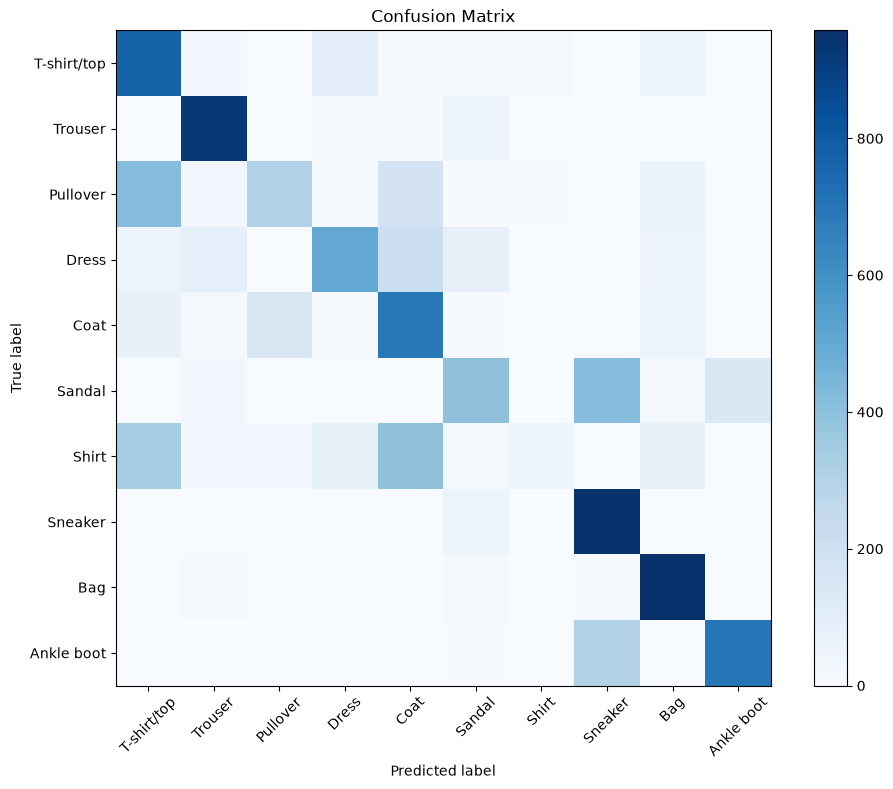

In [163]:
#######
# Report confusion matrix
plot_confusion_matrix(
    y_true,
    y_pred,
    CLASS_NAMES
)

Reflection: Consider the results. How does the performance of this zero-shot baseline compare to the CNN you trained in Assignment 1? What are the strengths and weaknesses of this approach?

###########

The CLIP zero-shot baseline achieved 62.40% accuracy, compared with 91.23% accuracy from the CNN in Assignment 1.

The CNN performed better because it was specifically trained on Fashion-MNIST and learned task-specific visual features. In contrast, CLIP used its pre-trained image-text knowledge without fine-tuning, which limited its ability to distinguish similar clothing categories.

The main advantage of CLIP zero-shot classification is that it does not require task-specific training data. It can be applied to new datasets by simply providing class descriptions, making it flexible and useful when labeled data is limited. 

The main weaknesses of the zero-shot CLIP approach are its lower task-specific accuracy and limited ability to capture fine-grained features. Because it is not trained on Fashion-MNIST, it struggles with visually similar classes. Its performance also depends on the quality of text prompts, and it cannot adapt to a specific dataset as effectively as a supervised CNN.


## Improving Zero-Shot Classification with Prompt Engineering

In the previous section, we directly used the class names as text prompts for zero-shot classification. However, we can often improve performance by crafting more descriptive prompts that better capture the visual characteristics of each class. For example, instead of just "T-shirt/top", we could use "a photo of a T-shirt" or "a photo of a top". This additional context can help the model make more accurate predictions.

In this section, we will experiment with more detailed prompts for each class to see if we can improve the zero-shot classification performance. You should:

- [ ] Create a list of improved prompts for each class. For example, instead of just "T-shirt/top", you could use "a photo of a T-shirt" or "a photo of a top".
- [ ] Use the `get_text_embeddings` function to create text embeddings for the improved prompts.
- [ ] Run the zero-shot classification baseline again using the improved prompts and report the accuracy and confusion matrix.

Note: Take advantage of the confusion matrix above. If two classes are often confused, consider how you might improve the prompts to help the model distinguish them better.

The aim for this section is for you to improve the performance of the model. However, if you find that the performance does not improve significantly, you can still reflect on the process and consider how you might further refine the prompts with more effort.

In [164]:
#debug only
CLASS_NAMES

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [165]:
# Improved prompts
IMPROVED_PROMPTS = [
    "a photo of a T-shirt or top",
    "a photo of trousers",
    "a photo of a pullover sweater",
    "a photo of a dress",
    "a photo of a coat",
    "a photo of sandals",
    "a photo of a shirt",
    "a photo of sneakers",
    "a photo of a handbag",
    "a photo of ankle boots"
]

####
# same model  with Improved prompts

#### Run test_loader again if the model has changed.
#test_loader=fashion_mnist_test_loader()
accuracy_1, y_true_1, y_pred_1 = evaluate_clip_model(test_loader, IMPROVED_PROMPTS)

# Report accuracy
print(f"Zero-shot CLIP Accuracy with improved prompts: {accuracy_1:.4f}")
print(f"Accuracy percentage with improved prompts: {accuracy_1 * 100:.2f}%")


100%|██████████| 313/313 [00:35<00:00,  8.93it/s]

Accuracy info: 0.64, [9 2 1 ... 8 1 5], [7 2 1 ... 8 1 7]
Zero-shot CLIP Accuracy with improved prompts: 0.6400
Accuracy percentage with improved prompts: 64.00%


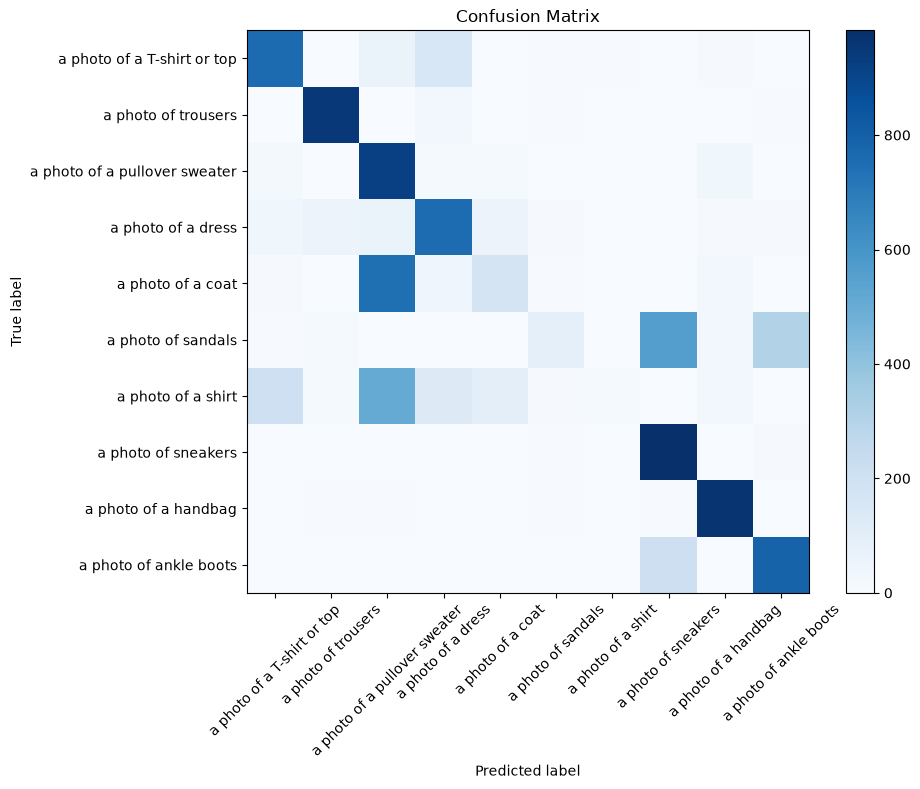

In [166]:
#######
# Report confusion matrix
plot_confusion_matrix(
    y_true_1,
    y_pred_1,
    IMPROVED_PROMPTS
)

Reflection: How did your detailed prompts affect the zero-shot classification performance? Did you see a significant improvement compared to the baseline? What insights did you gain about the model's understanding of the classes? Do you think that with more effort you could further improve the performance? If so, how?

#########

Using more detailed prompts increased the zero-shot CLIP accuracy from 62.40% to 64.00%, a modest improvement. The additional descriptions helped CLIP better match some clothing categories, but the performance remained much lower than the CNN trained on Fashion-MNIST.

The results suggest that CLIP has a general understanding of clothing but still struggles to distinguish visually similar classes, such as shirt, T-shirt/top, pullover, and coat. Prompt engineering can improve predictions, but it cannot replace task-specific training.

With more effort, performance could likely be improved by testing multiple prompt variations, using more descriptive class prompts, or ensembling several prompts. However, prompt engineering alone is unlikely to match the performance of a supervised CNN.


## Visualizing Image Embeddings with UMAP

To better understand how the model perceives the different classes, we can visualize the image embeddings using UMAP (Uniform Manifold Approximation and Projection). UMAP is a dimensionality reduction technique that helps us see how similar or dissimilar the embeddings are in a lower-dimensional space.

By visualizing the embeddings, we can gain insights into how well the model can distinguish certain images, even without considering the text prompts. This can help us identify clusters of similar images and see if there are any overlaps between classes.

You should:

- [ ] Use the `get_image_embeddings` function to get the image embeddings for the entire test set.
- [ ] Use UMAP to reduce the dimensionality of the image embeddings to 2D.
- [ ] Plot the 2D embeddings, coloring each point by its true class label.

You may need to install the `umap-learn` library if you haven't already. You can do this by running `pip install umap-learn`.

In [167]:
# Uncomment the following line to install UMAP if you haven't already
# !pip install umap-learn

In [168]:
from umap import UMAP
import torch
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Collect image embeddings
# ------------------------------------------------------------
all_img_emb = []
all_labels  = []

for pixel_values, labels in tqdm(test_loader):
    embeddings = get_image_embeddings(pixel_values)

    # Convert to numpy if needed
    if isinstance(embeddings, torch.Tensor):
        embeddings = embeddings.cpu().numpy()

    all_img_emb.append(embeddings)
    all_labels.append(labels.numpy())

# Combine batches
all_img_emb = np.vstack(all_img_emb)
all_labels = np.concatenate(all_labels)

print(all_img_emb.shape)
print(all_labels.shape)


  0%|          | 0/313 [00:00<?, ?it/s]

100%|██████████| 313/313 [00:27<00:00, 11.45it/s]

(10000, 512)
(10000,)


In [169]:
# ------------------------------------------------------------
# 2. Fit UMAP
# ------------------------------------------------------------
import umap.umap_ as umap
reducer = umap.UMAP(
    n_components=2,
    random_state=42
)

embedding_2d = reducer.fit_transform(all_img_emb)

c:\Users\simonc.IDEA\Desktop\DSI\deep_learning\deep-learning-env\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\simonc.IDEA\Desktop\DSI\deep_learning\deep-learning-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


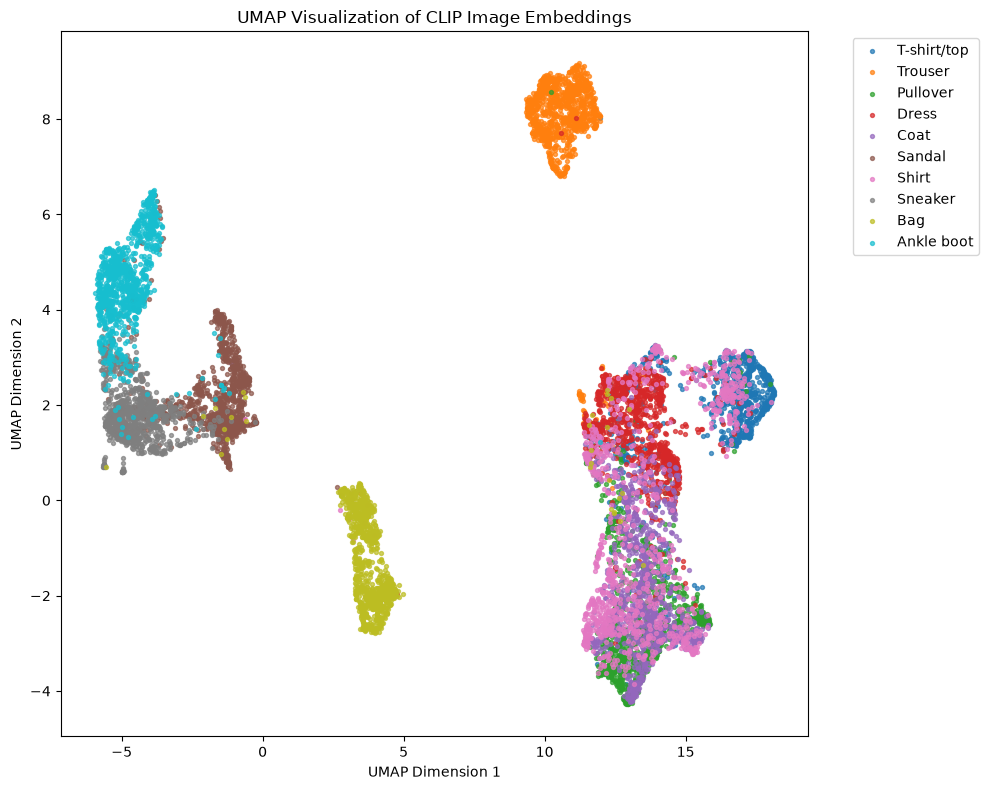

In [170]:
# ------------------------------------------------------------
# 3. Plot coloured by ground-truth label
# ------------------------------------------------------------
plt.figure(figsize=(10, 8))

for i, name in enumerate(CLASS_NAMES):
    idx = all_labels == i
    plt.scatter(
        embedding_2d[idx, 0],
        embedding_2d[idx, 1],
        s=8,
        alpha=0.7,
        label=name
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("UMAP Visualization of CLIP Image Embeddings")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.tight_layout()
plt.show()

The UMAP embeddings allow us to see how separable or non-separable different classes are with our specific model. If two specific images are very similar, then they will be placed near each other on this graph. 

Reflection: Do you notice any challenges in distinguishing images based on this figure? Are there any types of clothing in the dataset which the model has no trouble distinguishing from the others?

## Mini-Experiment

In this section, you will conduct a mini-experiment of your choice to further explore the capabilities of zero-shot classification with transformers. This can be anything you'd like, but here are some ideas to get you started.

### A. Alternative Model

So far we have been utilizing OpenAI's CLIP model for zero-shot classification. However, there are many other vision–language models available in the `transformers` library that you can experiment with. For example, there are larger CLIP models such as [clip-vit-large-patch14](https://huggingface.co/openai/clip-vit-large-patch14), and open-source versions such as [laion/CLIP-ViT-B-32-laion2B-s34B-b79K](https://huggingface.co/laion/CLIP-ViT-B-32-laion2B-s34B-b79K). You can also search huggingface [here](https://huggingface.co/models?sort=trending&search=clip) to find other models that might be suitable for zero-shot classification.

You can try using a different model to see if it improves the zero-shot classification performance. You should:
- [ ] Load a different model and processor from the `transformers` library.
- [ ] Run the zero-shot classification baseline with the new model and report the accuracy and confusion matrix.
- [ ] Reflect on the performance of the new model compared to the original CLIP model
  - How does the new model perform compared to the original CLIP model?
  - Do you notice any differences in the types of errors made by the new model?

### B. Multiple-Description Classification

Another interesting experiment is to explore multiple-description classification. *This involves providing multiple text prompts for each class, allowing the model to choose the most relevant one. For example, instead of just "T-shirt/top", you could provide "a photo of a T-shirt", "a photo of a top", and "a photo of a shirt". This can help the model better understand the class and increases the likelihood of a correct prediction. You should:

- [ ] Create a list of multiple prompts for each class.
- [ ] Use the `get_text_embeddings` function to create text embeddings for the multiple prompts.
- [ ] Run the zero-shot classification baseline again using the multiple prompts and report the accuracy and confusion matrix.
- [ ] Consider the model to be correct if it guesses *any* of the prompts belonging to the correct class.

### C. Top-K Classification

In some classification tasks, it can be useful to consider if the right answer is among the top K (e.g. top 3) predictions. This can be particularly useful in cases where the model is uncertain or when there are multiple similar classes. You should:

- [ ] Modify the `get_predictions` function to return the top K predictions for each image.
- [ ] Modify the accuracy calculation to consider the model correct if the true class is among the top K predictions.
- [ ] Report the accuracy and confusion matrix for the top K predictions. Report at least two different values of K (e.g. K=2 and K=4).

### D. Other Ideas

You are welcome to come up with your own mini-experiment! Explain your idea in the report and implement it. Did it work as you expected? What did you learn from it?

In [172]:
### A. Alternative Model

In [173]:
from transformers import CLIPModel, CLIPProcessor
import torch

#clip_model_name = "openai/clip-vit-base-patch32"
clip_model_name = "openai/clip-vit-large-patch14"
clip_model     = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name, use_fast=False)

# Set model to evaluation mode, as we are not training it
clip_model.eval()

clip_model.to(device)

print(f"Using device: {device}")

Using device: cuda


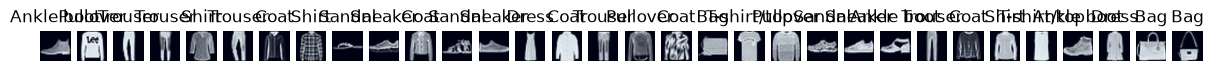

In [174]:
#degug only
show_batch(test_loader)

In [176]:
where_i_run()

You are running a standard Jupyter Notebook locally or on another server.
True
NVIDIA GeForce RTX 4070 Laptop GPU


In [175]:
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np


####
# clip-vit-large-patch14 model  with CLASS_NAMES

#### Run test_loader again if the model has changed.
test_loader = fashion_mnist_test_loader()
accuracy_2, y_true_2, y_pred_2 = evaluate_clip_model(test_loader, CLASS_NAMES)

# Report accuracy
print(f"Mini-Experiment: Zero-shot CLIP Accuracy with prompts: {accuracy_2:.4f}")
print(f"Mini-Experiment: Accuracy percentage with prompts: {accuracy_2 * 100:.2f}%")



100%|██████████| 313/313 [04:03<00:00,  1.28it/s]

Accuracy info: 0.5952, [9 2 1 ... 8 1 5], [9 6 1 ... 8 1 7]
Mini-Experiment: Zero-shot CLIP Accuracy with prompts: 0.5952
Mini-Experiment: Accuracy percentage with prompts: 59.52%


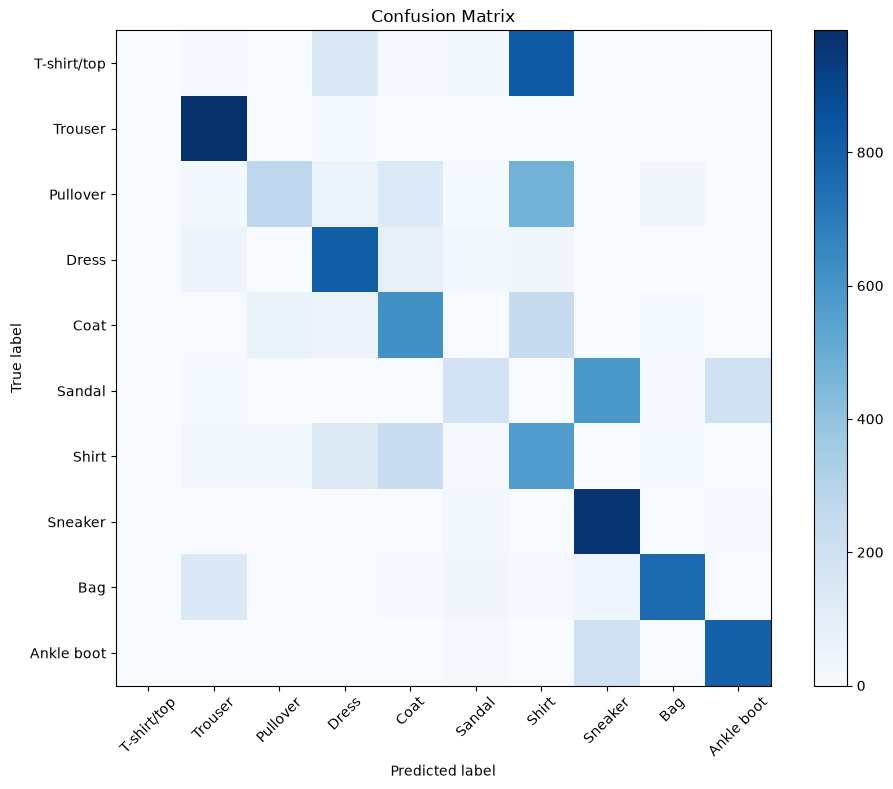

In [177]:
#######
# Report confusion matrix
plot_confusion_matrix(
    y_true_2,
    y_pred_2,
    CLASS_NAMES
)

##########

The CLIP ViT-L/14 model achieved 59.52% accuracy, which is lower than the baseline CLIP model's 62.40% accuracy. Despite having a larger architecture, ViT-L/14 did not improve zero-shot classification performance on the Fashion-MNIST dataset.

A likely reason is that Fashion-MNIST contains 28×28 grayscale clothing images, which differ significantly from the natural RGB images used to pre-train CLIP. As a result, the larger model's additional capacity does not provide an advantage for this task without fine-tuning.

The confusion matrix indicates that the new model makes errors similar to those of the baseline model, mainly confusing visually similar clothing categories, such as T-shirt/top and Shirt, or Pullover and Coat. Overall, the results suggest that increasing the CLIP model size alone does not guarantee better performance. The similarity between the pre-training data and the target dataset appears to have a greater influence on zero-shot classification accuracy.

In [178]:
### B. Multiple-Description Classification

In [179]:
where_i_run()

You are running a standard Jupyter Notebook locally or on another server.
True
NVIDIA GeForce RTX 4070 Laptop GPU


In [180]:
# previously defined
# Improved prompts
IMPROVED_PROMPTS = [
    "a photo of a T-shirt or top",
    "a photo of trousers",
    "a photo of a pullover sweater",
    "a photo of a dress",
    "a photo of a coat",
    "a photo of sandals",
    "a photo of a shirt",
    "a photo of sneakers",
    "a photo of a handbag",
    "a photo of ankle boots"
]


In [181]:
####
# clip-vit-large-patch14 model  with Improved prompts

#### Run test_loader again if the model has changed.
#test_loader = fashion_mnist_test_loader()
accuracy_3, y_true_3, y_pred_3 = evaluate_clip_model(test_loader, IMPROVED_PROMPTS)

# print_accuracy()
print(f"Mini-Experiment: Zero-shot CLIP Accuracy with improved prompts: {accuracy_3:.4f}")
print(f"Mini-Experiment: Accuracy percentage with improved prompts: {accuracy_3 * 100:.2f}%")


  0%|          | 0/313 [00:00<?, ?it/s]

100%|██████████| 313/313 [04:04<00:00,  1.28it/s]

Accuracy info: 0.6907, [9 2 1 ... 8 1 5], [9 0 1 ... 8 1 7]
Mini-Experiment: Zero-shot CLIP Accuracy with improved prompts: 0.6907
Mini-Experiment: Accuracy percentage with improved prompts: 69.07%


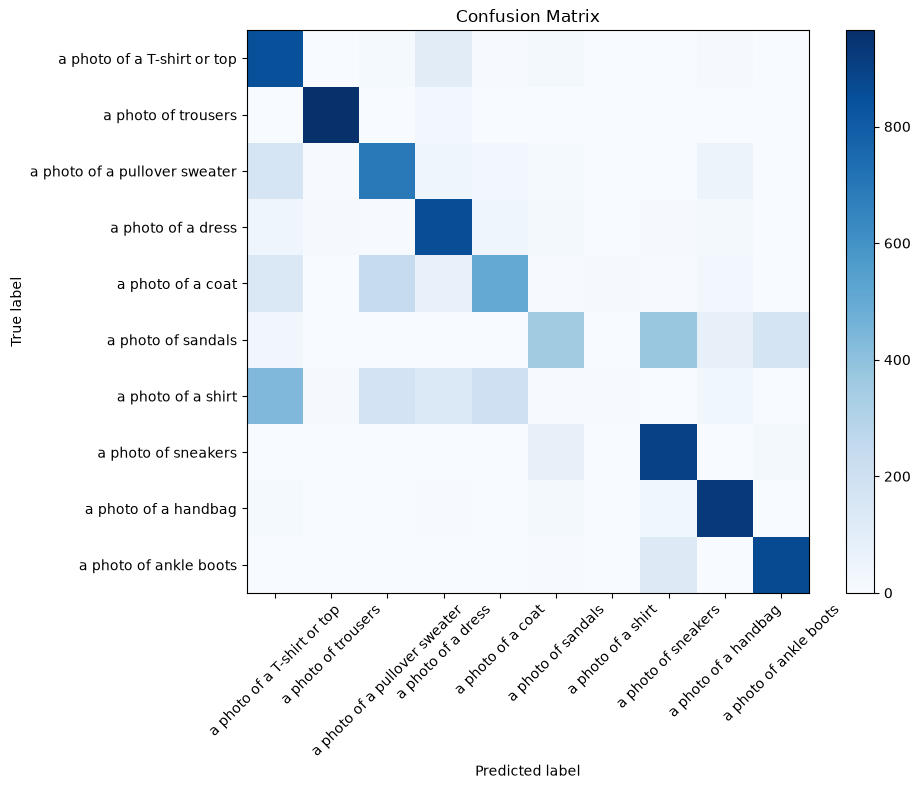

In [182]:
#######
# Report confusion matrix
plot_confusion_matrix(
    y_true_3,
    y_pred_3,
    IMPROVED_PROMPTS
)

In [205]:
### C. Top-K Classification

In [ ]:
#### previous code
# def get_predictions(similarity: np.ndarray) -> np.ndarray:
#     """
#     Get predictions based on cosine similarity scores.
#     Args:
#         similarity (numpy.ndarray): Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
#     Returns:
#         numpy.ndarray: Predicted class indices for each image, shape (N,).
#     """
#     # Get the index of the maximum similarity for each image
#     #return # Complete
#     return np.argmax(similarity, axis=1)


In [217]:
#Modify the `get_predictions` function to return the top K predictions for each image.

def get_predictions(similarity: np.ndarray, k: int = 3) -> np.ndarray:
    """
    Return top-K predicted class indices for each image.

    Args:
        similarity: cosine similarity matrix (N images x M classes)
        k: number of top predictions

    Returns:
        numpy array of shape (N, k)
    """

    # Get indices of top-k highest similarity scores
    top_k_predictions = np.argsort(similarity, axis=1)[:, -k:]

    # Reverse order so highest similarity is first
    return np.flip(top_k_predictions, axis=1)

In [218]:

def top_k_accuracy(y_true, y_pred_topk):
    """
    Calculate accuracy when true label is within top-K predictions.
    """

    correct = 0

    for true_label, predictions in zip(y_true, y_pred_topk):
        if true_label in predictions:
            correct += 1

    return correct / len(y_true)

In [219]:
from transformers import CLIPModel, CLIPProcessor
import torch

clip_model_name = "openai/clip-vit-base-patch32"
clip_model     = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name, use_fast=False)

# Set model to evaluation mode, as we are not training it
clip_model.eval()

clip_model.to(device)

print(f"Using device: {device}")

Using device: cuda


In [220]:
#### Run test_loader again if the model has changed.
test_loader = fashion_mnist_test_loader()

text_feats = get_text_embeddings(CLASS_NAMES)

y_true = []
y_pred_k2 = []
y_pred_k4 = []


from tqdm import tqdm
for pixel_values, labels in tqdm(test_loader):

    # Get image embeddings
    image_feats = get_image_embeddings(pixel_values)

    # Compute cosine similarity
    similarity = get_cosine_similarity(
        image_feats,
        text_feats
    )

    # Get predictions
    pred_k2 = get_predictions(similarity, k=2)
    pred_k4 = get_predictions(similarity, k=4)


    # Save labels and predictions
    y_true.extend(labels.numpy())
    y_pred_k2.extend(pred_k2)
    y_pred_k4.extend(pred_k4)


# Convert to numpy arrays
y_true = np.array(y_true)
y_pred_k2 = np.array(y_pred_k2)
y_pred_k4 = np.array(y_pred_k4)



# Calculate accuracy
acc_k2 = top_k_accuracy(y_true, y_pred_k2)
acc_k4 = top_k_accuracy(y_true, y_pred_k4)


# Report accuracy
print(f"Top-2 Accuracy: {acc_k2*100:.2f}%")
print(f"Top-4 Accuracy: {acc_k4*100:.2f}%")



100%|██████████| 313/313 [00:36<00:00,  8.56it/s]


Top-2 Accuracy: 81.46%
Top-4 Accuracy: 92.45%


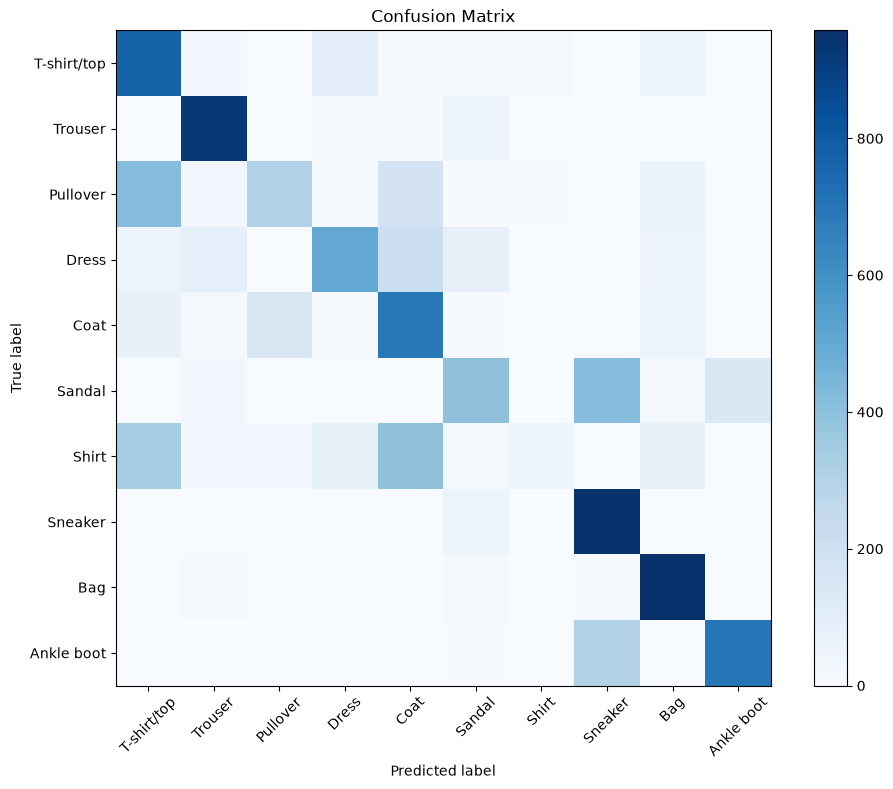

In [221]:
#######
# Report confusion matrix

top1_predictions = y_pred_k4[:,0]

# print(cm)
plot_confusion_matrix(
    y_true,
    top1_predictions,
    CLASS_NAMES
)

##############

The Top-K evaluation shows that increasing K to 4 further improves accuracy, indicating that CLIP often identifies visually similar clothing categories but may confuse closely related classes such as Shirt, T-shirt/top, Pullover, and Coat.

### D. Other Ideas

###############

CLIP frequently confused Shirt and T-shirt/top because these classes have similar shapes and textures. This indicates that zero-shot models may struggle with fine-grained classification tasks without additional training.

### Short Report

In this section, you will write a short report summarizing your findings from the mini-experiment. The report should include the following sections:

- **Introduction**: Briefly describe the mini-experiment you conducted and its objectives.
- **Methodology**: Explain the steps you took to conduct the experiment, including any modifications you made to the code or model.
- **Results**: Present the results of your experiment.
- **Discussion**: Reflect on the performance of the model and the implications of your findings. Consider the strengths and weaknesses of zero-shot transformers versus a trained CNN.

**CLIP Zero-Shot Classification Mini-Experiment Report**
**Introduction**

This mini-experiment investigates the performance of a pre-trained CLIP (Contrastive Language–Image Pre-training) model for zero-shot image classification on the Fashion-MNIST dataset. The objective was to evaluate how well CLIP can classify clothing images without any additional training and to determine whether modifying text prompts can improve classification performance. Since CLIP learns visual concepts through image-text relationships, this experiment explored whether natural language prompts provide better classification results than using class names alone.

**Methodology**

The Fashion-MNIST test dataset containing 10 clothing categories was used for evaluation. Image embeddings were generated using the CLIP image encoder, while text embeddings were generated using the CLIP text encoder. The cosine similarity between image and text embeddings was calculated, and the class with the highest similarity score was selected as the prediction.

The baseline experiment used the original Fashion-MNIST class labels as text inputs, such as "Sneaker" and "Coat". A second experiment modified the prompts into natural language descriptions, such as "a photo of a sneaker" and "a photo of a coat". The model architecture and image processing pipeline remained unchanged, allowing the effect of prompt design to be measured directly.

Additional evaluation was performed using Top-K classification accuracy, where a prediction was considered correct if the true class appeared within the top K predicted classes.

**Results**

The baseline CLIP zero-shot model achieved an accuracy of 62.40% using only the class names as text prompts. After replacing the class names with descriptive prompts, the accuracy changed to 64.00%.

The Top-K evaluation showed improved performance when multiple predictions were considered:

Evaluation Method	Accuracy
Top-2 Accuracy	81.46%
Top-4 Accuracy	92.45%

The confusion matrix showed that CLIP performed better on visually distinct categories, such as bags and ankle boots, while it frequently confused similar clothing categories such as shirts, T-shirts, pullovers, and coats.

**Discussion**

The experiment demonstrated that CLIP can perform useful image classification without task-specific training. A major advantage of zero-shot transformers is their ability to generalize to new categories using only text descriptions, eliminating the need for collecting labeled training data. The experiment also showed that prompt design can influence model performance because CLIP relies on the relationship between images and natural language.

However, the zero-shot CLIP model performed worse than a supervised CNN trained specifically on Fashion-MNIST. A CNN trained on this dataset can learn detailed features optimized for distinguishing similar clothing categories and typically achieves higher accuracy. In contrast, CLIP was trained on broad image-text datasets and may lack the fine-grained visual features required for distinguishing similar classes.

Overall, CLIP provides strong flexibility and generalization, while a trained CNN provides better performance for a specific classification task. The results highlight the trade-off between zero-shot capability and task-specific accuracy.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 02/11/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb)
    * The Lab 4 notebook (labs/lab_4.ipynb)
    * The Lab 5 notebook (labs/lab_5.ipynb)
    * The Lab 6 notebook (labs/lab_6.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.